[3.14193116e-14 2.84217094e-14 1.41421356e+02 1.45654151e-14
 1.61022732e-14 7.07106781e+01 0.00000000e+00 1.27903188e-14
 5.25915934e-15 1.69637580e-14 2.90766604e-14 1.85521850e-14
 2.10158386e-14 8.68831862e-15 1.58435235e-14 5.27594736e-15
 1.98578677e-14 7.32834681e-15 1.09478663e-14 7.81840836e-15
 4.71237445e-15 2.86951292e-14 1.88462490e-14 8.10143532e-15
 9.17921405e-16 4.96999031e-15 5.28359199e-15 7.80943052e-15
 1.21272662e-15 2.50534132e-15 4.93636053e-15 1.45649398e-15
 7.96892359e-15 5.75287185e-15 1.33587591e-14 1.92004485e-15
 5.13560495e-15 4.53720862e-15 6.65169015e-15 1.75700231e-15
 1.58840413e-15 5.41351313e-15 8.35865645e-16 0.00000000e+00
 7.10542736e-15 1.15061616e-16 4.97451009e-15 7.10542736e-15
 7.10542736e-15 7.88258347e-15]


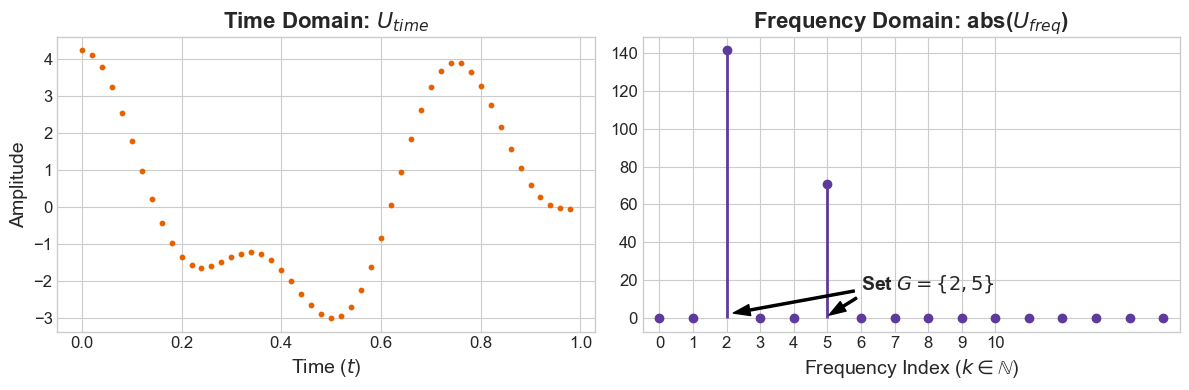

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.fft import dct

# --- 1. Data Generation (Your exact code) ---
n = 50
T = 1.0  # Time horizon
t = np.linspace(0, T, n, endpoint=False)

# G = {2, 5}
k1, k2 = 2, 5

U_time = 2.0 * math.sqrt(2) * np.cos(np.pi * t * (k1 + 0.5)) + 1.0 * math.sqrt(2) * np.cos(np.pi * t * (k2 + 0.5))

U_freq = dct(U_time, type=3)
k_indices = np.arange(len(U_freq))
magnitude = np.abs(U_freq)
print(magnitude)

# --- 2. Plotting Code ---
# Use a clean, professional style for presentations
plt.style.use('seaborn-v0_8-whitegrid') 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Time Domain
ax1.scatter(t, U_time, color='#E66100', s=10, alpha=1)
ax1.set_title('Time Domain: $U_{time}$', fontsize=16, fontweight='bold')
ax1.set_xlabel('Time ($t$)', fontsize=14)
ax1.set_ylabel('Amplitude', fontsize=14)
ax1.tick_params(axis='both', labelsize=12)
# Plot 2: Frequency Domain
# We use a stem plot to emphasize that these are discrete integer bins (natural numbers)
markerline, stemlines, baseline = ax2.stem(k_indices, magnitude, linefmt='#5D3A9B', markerfmt='o', basefmt=" ")
plt.setp(stemlines, 'linewidth', 2)
plt.setp(markerline, 'markersize', 6)

ax2.set_title('Frequency Domain: abs($U_{freq}$)', fontsize=16, fontweight='bold')
ax2.set_xlabel('Frequency Index ($k \in \mathbb{N}$)', fontsize=14)
ax2.set_xlim(-0.5, 15.5) # Zoom in to indices 0 through 10 (since the rest are zero)
ax2.set_xticks(np.arange(0, 11, 1)) # Force integer ticks to show natural numbers
ax2.tick_params(axis='both', labelsize=12)

# Annotate the sparse set G
ax2.annotate('Set $G=\{2, 5\}$', xy=(k2, 1.05), xytext=(6, 15),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=14, fontweight='bold')
ax2.annotate('', xy=(k1, 2.05), xytext=(6, 15),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))

plt.tight_layout()
plt.savefig('sparse_U_example.pdf', format='pdf', bbox_inches='tight')
plt.show()